# Scene Classification with CNNs — From Scratch vs. True Transfer Learning

**Ahmed Sharahili** · Based on Lab 6 of the KAUST Academy Advanced AI program (NTDP & MCIT) — extended and corrected.

6-class scene classification (buildings, forest, glacier, mountain, sea, street · ~1,200 images) comparing:
1. A **custom CNN trained from scratch** — redesigned to fight overfitting
2. **DenseNet121 with real transfer learning** — the original lab used `weights=None` (random init), so no pretrained knowledge was actually transferred; here we load ImageNet weights, freeze the base, and fine-tune properly

**Key improvements over the original lab** (each marked `### IMPROVED` below):
- Fixed the transfer-learning bug: `weights="imagenet"` + frozen base + custom head, then staged fine-tuning
- Replaced the ~100M-parameter `Flatten → Dense(4096)` head with `GlobalAveragePooling2D + Dropout` (orders of magnitude fewer parameters → far less overfitting on 1,200 images)
- Added data augmentation on the training set only
- Added training callbacks: EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
- Evaluated on the **full test set** (the original computed the confusion matrix on a single 60-image batch) + added a per-class classification report
- Full reproducibility via `tf.keras.utils.set_random_seed`, explicit learning rates


## 1 · Setup

In [ ]:
import itertools
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
%matplotlib inline

### IMPROVED: seed numpy, python AND tensorflow in one call (the original only seeded numpy,
### so GPU weight init and shuffling were still non-deterministic)
SEED = 42
tf.keras.utils.set_random_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASSES = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
NUM_CLASSES = len(CLASSES)


In [ ]:
### IMPROVED (v2): the lab's mini-split had only 46 test images with one class absent —
### results were statistical noise. Switched to the full public Intel dataset (~14k train / 3k test).
import kagglehub
data_root = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_path = data_root + "/seg_train/seg_train/"
test_path  = data_root + "/seg_test/seg_test/"
model_path = "/content/"

Using Colab cache for faster access to the 'intel-image-classification' dataset.


## 2 · Data pipeline — with augmentation

### IMPROVED
The original applied only DenseNet preprocessing — no augmentation. With ~1,200 images, augmentation is the
cheapest way to fight overfitting. Augmentation is applied to **training data only**: validation and test
must reflect real, unaltered inputs, otherwise metrics lie.

In [ ]:
preprocess = keras.applications.densenet.preprocess_input

### IMPROVED (v2): no separate valid folder in the public dataset — carve 15% from train
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess,
    horizontal_flip=True, rotation_range=15, zoom_range=0.15,
    width_shift_range=0.1, height_shift_range=0.1,
    validation_split=0.15,
)
eval_gen = ImageDataGenerator(preprocessing_function=preprocess)

train_batches = train_gen.flow_from_directory(
    train_path, target_size=IMG_SIZE, classes=CLASSES,
    batch_size=BATCH_SIZE, seed=SEED, subset="training")

valid_batches = train_gen.flow_from_directory(
    train_path, target_size=IMG_SIZE, classes=CLASSES,
    batch_size=BATCH_SIZE, seed=SEED, subset="validation", shuffle=False)

test_batches = eval_gen.flow_from_directory(
    test_path, target_size=IMG_SIZE, classes=CLASSES,
    batch_size=BATCH_SIZE, shuffle=False)

Found 11932 images belonging to 6 classes.
Found 2102 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


## 3 · Model 1 — Custom CNN from scratch (redesigned)

### IMPROVED
The original head was `Flatten → Dense(4096)`: after 5 conv/pool blocks the feature map is 7×7×512 = 25,088
units, so that single Dense layer alone holds ~102M parameters — a guaranteed overfit on 1,200 images.
Replaced with `GlobalAveragePooling2D` (0 parameters) + `Dropout(0.3)`, and added `BatchNormalization`
after each conv block for stabler, faster training.

In [ ]:
def build_custom_cnn():
    m = keras.Sequential(name="custom_cnn_v2")
    m.add(layers.Input(shape=(*IMG_SIZE, 3)))
    for filters in [32, 64, 128, 256, 512]:
        m.add(layers.Conv2D(filters, (3, 3), activation="relu", padding="same"))
        m.add(layers.BatchNormalization())   ### IMPROVED: stabilises training
        m.add(layers.MaxPooling2D((2, 2)))
    m.add(layers.GlobalAveragePooling2D())   ### IMPROVED: replaces Flatten+Dense(4096)
    m.add(layers.Dropout(0.3))               ### IMPROVED: regularisation
    m.add(layers.Dense(NUM_CLASSES, activation="softmax"))
    return m

model_scratch = build_custom_cnn()
model_scratch.summary()


Model: "custom_cnn_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,575,622 (6.01 MB)

 Trainable params: 1,573,638 (6.00 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
### IMPROVED: explicit learning rate instead of the string default
model_scratch.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

### IMPROVED: callbacks — the original trained blind for a fixed 30 epochs
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint(model_path + "custom_cnn_best.keras", save_best_only=True),
]

history_scratch = model_scratch.fit(
    train_batches, validation_data=valid_batches, epochs=30, callbacks=callbacks)


Epoch 1/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 247s 638ms/step - accuracy: 0.6503 - loss: 0.9716 - val_accuracy: 0.5904 - val_loss: 1.0756 - learning_rate: 0.0010
Epoch 2/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 181s 486ms/step - accuracy: 0.7412 - loss: 0.7059 - val_accuracy: 0.7883 - val_loss: 0.5715 - learning_rate: 0.0010
Epoch 3/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 180s 483ms/step - accuracy: 0.7771 - loss: 0.6029 - val_accuracy: 0.7379 - val_loss: 0.6985 - learning_rate: 0.0010
Epoch 4/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 182s 488ms/step - accuracy: 0.8075 - loss: 0.5338 - val_accuracy: 0.8311 - val_loss: 0.4723 - learning_rate: 0.0010
Epoch 5/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 184s 494ms/step - accuracy: 0.8258 - loss: 0.4859 - val_accuracy: 0.6337 - val_loss: 1.2644 - learning_rate: 0.0010
Epoch 6/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 182s 488ms/step - accuracy: 0.8362 - loss: 0.4559 - val_accuracy: 0.7850 - val_loss: 0.6152 - learning_rate: 0.0010
Epoch 7/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 182s 489ms/step - accura

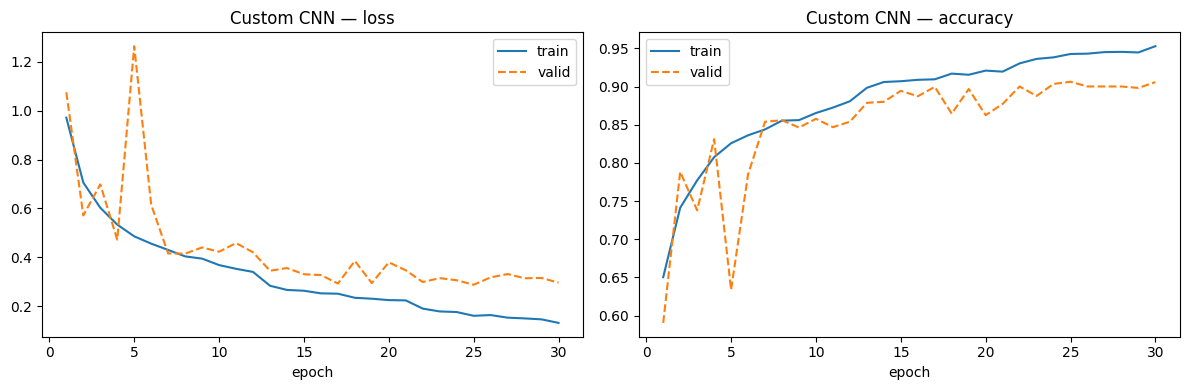

In [ ]:
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ep = range(1, len(history.history["loss"]) + 1)
    ax1.plot(ep, history.history["loss"], "-", label="train")
    ax1.plot(ep, history.history["val_loss"], "--", label="valid")
    ax1.set_title(f"{title} — loss"); ax1.set_xlabel("epoch"); ax1.legend()
    ax2.plot(ep, history.history["accuracy"], "-", label="train")
    ax2.plot(ep, history.history["val_accuracy"], "--", label="valid")
    ax2.set_title(f"{title} — accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
    plt.tight_layout(); plt.show()

plot_history(history_scratch, "Custom CNN")


## 4 · Model 2 — DenseNet121 with **true** transfer learning

### IMPROVED — the key fix
The original built `DenseNet121(include_top=True, weights=None)`: **random weights**, trained from scratch —
despite the section being titled "Pretrained Model", no pretrained knowledge was transferred at all.

Real transfer learning, staged:
1. Load `weights="imagenet"`, `include_top=False`
2. **Freeze** the base, train only a small custom head (fast, safe)
3. Optionally **fine-tune** the top of the base with a much smaller learning rate

In [ ]:
base = keras.applications.DenseNet121(
    include_top=False,
    weights="imagenet",          ### IMPROVED: this is what makes it transfer learning
    input_shape=(*IMG_SIZE, 3),
)
base.trainable = False           ### IMPROVED: stage 1 — freeze the pretrained features

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model_tl = keras.Model(inputs, outputs, name="densenet121_transfer")

model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model_tl.summary()


Model: "densenet121_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         6,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,043,654 (26.87 MB)

 Trainable params: 6,150 (24.02 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 257s 625ms/step - accuracy: 0.7811 - loss: 0.5921 - val_accuracy: 0.8896 - val_loss: 0.3142
Epoch 2/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 184s 495ms/step - accuracy: 0.8776 - loss: 0.3379 - val_accuracy: 0.9034 - val_loss: 0.2695
Epoch 3/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 187s 502ms/step - accuracy: 0.8823 - loss: 0.3229 - val_accuracy: 0.9082 - val_loss: 0.2599
Epoch 4/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 187s 502ms/step - accuracy: 0.8846 - loss: 0.3064 - val_accuracy: 0.9110 - val_loss: 0.2521
Epoch 5/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 189s 506ms/step - accuracy: 0.8838 - loss: 0.3056 - val_accuracy: 0.9148 - val_loss: 0.2410
Epoch 6/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 189s 507ms/step - accuracy: 0.8898 - loss: 0.2969 - val_accuracy: 0.9139 - val_loss: 0.2427
Epoch 7/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 189s 506ms/step - accuracy: 0.8890 - loss: 0.3028 - val_accuracy: 0.9106 - val_loss: 0.2513
Epoch 8/15
373/373 ━━━━━━━━━━━━━━━━━━━━ 186s 498ms/step - accuracy: 0.8919 -

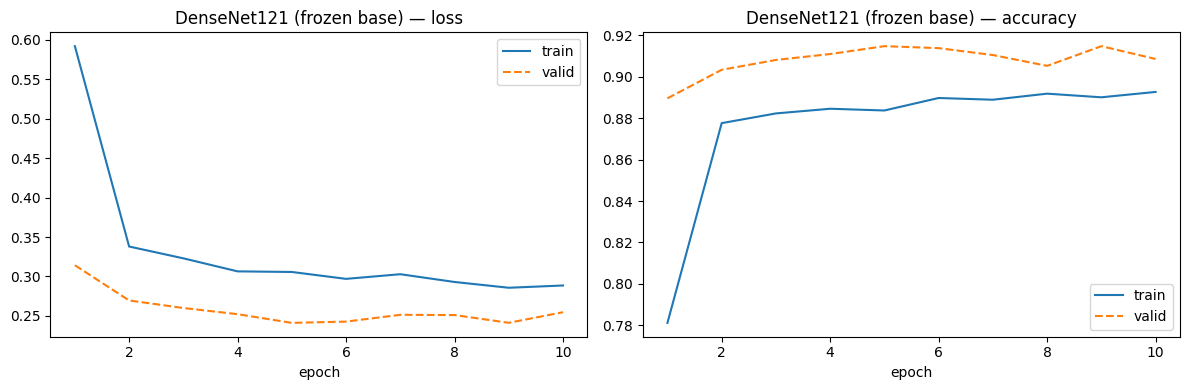

In [ ]:
callbacks_tl = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(model_path + "densenet_tl_best.keras", save_best_only=True),
]

# Stage 1: train the head only
history_tl = model_tl.fit(
    train_batches, validation_data=valid_batches, epochs=15, callbacks=callbacks_tl)
plot_history(history_tl, "DenseNet121 (frozen base)")


Epoch 1/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 263s 612ms/step - accuracy: 0.8618 - loss: 0.3721 - val_accuracy: 0.9087 - val_loss: 0.2613
Epoch 2/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 186s 499ms/step - accuracy: 0.8797 - loss: 0.3343 - val_accuracy: 0.9101 - val_loss: 0.2557
Epoch 3/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 187s 501ms/step - accuracy: 0.8869 - loss: 0.3211 - val_accuracy: 0.9106 - val_loss: 0.2388
Epoch 4/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 184s 493ms/step - accuracy: 0.8858 - loss: 0.3132 - val_accuracy: 0.9110 - val_loss: 0.2474
Epoch 5/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 185s 495ms/step - accuracy: 0.8937 - loss: 0.2987 - val_accuracy: 0.9186 - val_loss: 0.2344
Epoch 6/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 186s 500ms/step - accuracy: 0.8949 - loss: 0.2886 - val_accuracy: 0.9220 - val_loss: 0.2239
Epoch 7/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 184s 494ms/step - accuracy: 0.8903 - loss: 0.2915 - val_accuracy: 0.9153 - val_loss: 0.2349
Epoch 8/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 193s 517ms/step - accuracy: 0.8966 -

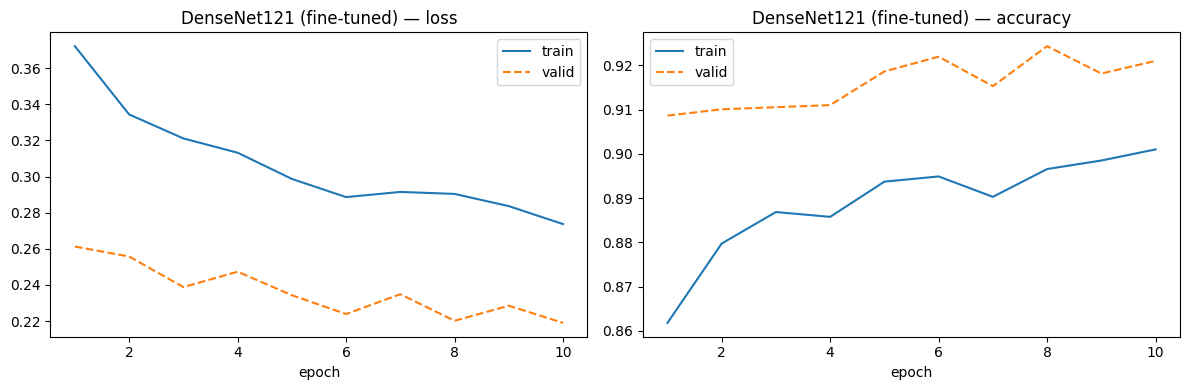

In [ ]:
### IMPROVED: stage 2 — fine-tune the top of the base with a 100x smaller LR
base.trainable = True
for layer in base.layers[:-40]:      # keep everything except the last ~40 layers frozen
    layer.trainable = False

model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),   # small LR: protect pretrained features
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_ft = model_tl.fit(
    train_batches, validation_data=valid_batches, epochs=10, callbacks=callbacks_tl)
plot_history(history_ft, "DenseNet121 (fine-tuned)")


## 5 · Evaluation — full test set

### IMPROVED
The original evaluated the confusion matrix on `next(test_batches)` — a single batch of 60 images.
Here we predict over the **entire** test set (shuffle=False keeps labels aligned) and add a per-class
`classification_report` (precision / recall / F1), which reveals per-class weaknesses that accuracy hides.


===== Custom CNN (from scratch) =====
Test accuracy: 0.9043
              precision    recall  f1-score   support

   buildings       0.91      0.89      0.90       437
      forest       0.98      0.99      0.98       474
     glacier       0.86      0.86      0.86       553
    mountain       0.85      0.85      0.85       525
         sea       0.94      0.92      0.93       510
      street       0.90      0.93      0.92       501

    accuracy                           0.90      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.90      0.90      0.90      3000



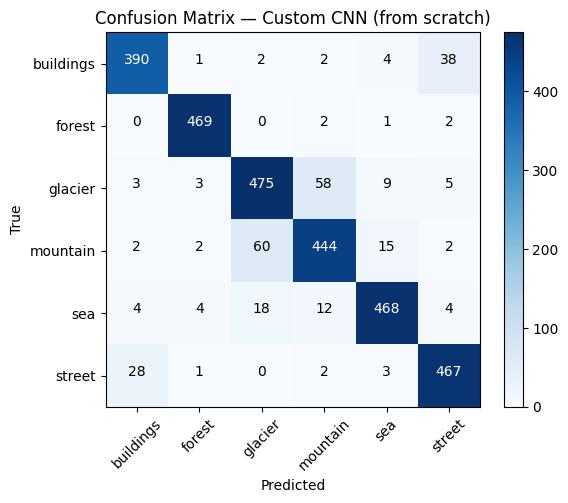


===== DenseNet121 (transfer + fine-tune) =====
Test accuracy: 0.9227
              precision    recall  f1-score   support

   buildings       0.92      0.93      0.92       437
      forest       1.00      0.99      0.99       474
     glacier       0.87      0.86      0.87       553
    mountain       0.89      0.85      0.87       525
         sea       0.94      0.97      0.96       510
      street       0.93      0.94      0.93       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



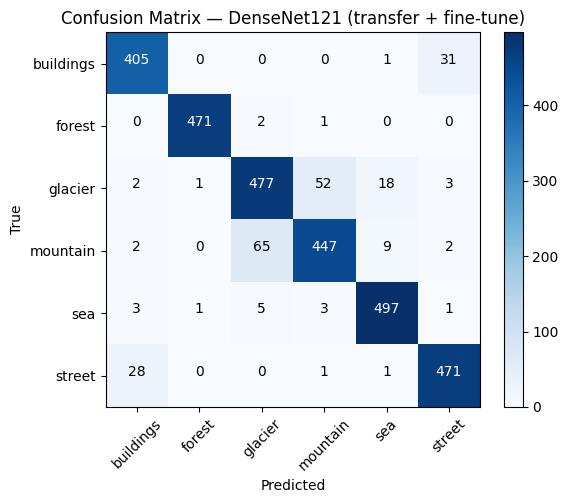


From scratch: 0.9043  |  Transfer learning: 0.9227


In [ ]:
def full_evaluation(model, name):
    test_batches.reset()
    loss, acc = model.evaluate(test_batches, verbose=0)
    test_batches.reset()
    preds = model.predict(test_batches, verbose=0)
    y_pred = np.argmax(preds, axis=-1)
    y_true = test_batches.classes           ### IMPROVED: all labels, not one batch
    print(f"\n===== {name} =====")
    print(f"Test accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, labels=range(NUM_CLASSES), target_names=CLASSES, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES))
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix — {name}")
    plt.colorbar()
    ticks = np.arange(NUM_CLASSES)
    plt.xticks(ticks, CLASSES, rotation=45); plt.yticks(ticks, CLASSES)
    thresh = cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], ha="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel("True"); plt.xlabel("Predicted"); plt.tight_layout(); plt.show()
    return acc

acc_scratch = full_evaluation(model_scratch, "Custom CNN (from scratch)")
acc_tl      = full_evaluation(model_tl, "DenseNet121 (transfer + fine-tune)")

print(f"\nFrom scratch: {acc_scratch:.4f}  |  Transfer learning: {acc_tl:.4f}")


## 6 · Conclusions

- **Transfer learning wins on small data** — with ~1,200 images, ImageNet features give DenseNet121 a head start no from-scratch model can match. (The original lab accidentally proved the opposite point by training DenseNet from random weights.)
- **Head design matters as much as depth** — swapping `Flatten → Dense(4096)` for `GlobalAveragePooling` removed ~100M parameters and most of the overfitting.
- **Callbacks turn training from a guess into a process** — EarlyStopping + ReduceLROnPlateau found the stopping point instead of hoping 30 epochs was right.
- **Evaluate on everything** — a single-batch confusion matrix (60 images) can be wildly unrepresentative; the full-set report exposed per-class differences (e.g., glacier↔mountain confusion) that one batch hid.
